Loaded 8 methods: ['ERM', 'WFR(Xu, 2025)', 'Particle Ascent', 'Dual(Wang et al., 2021)', 'Madry PGD', 'PPA', 'WDRO-NPF', 'NN-DRO']


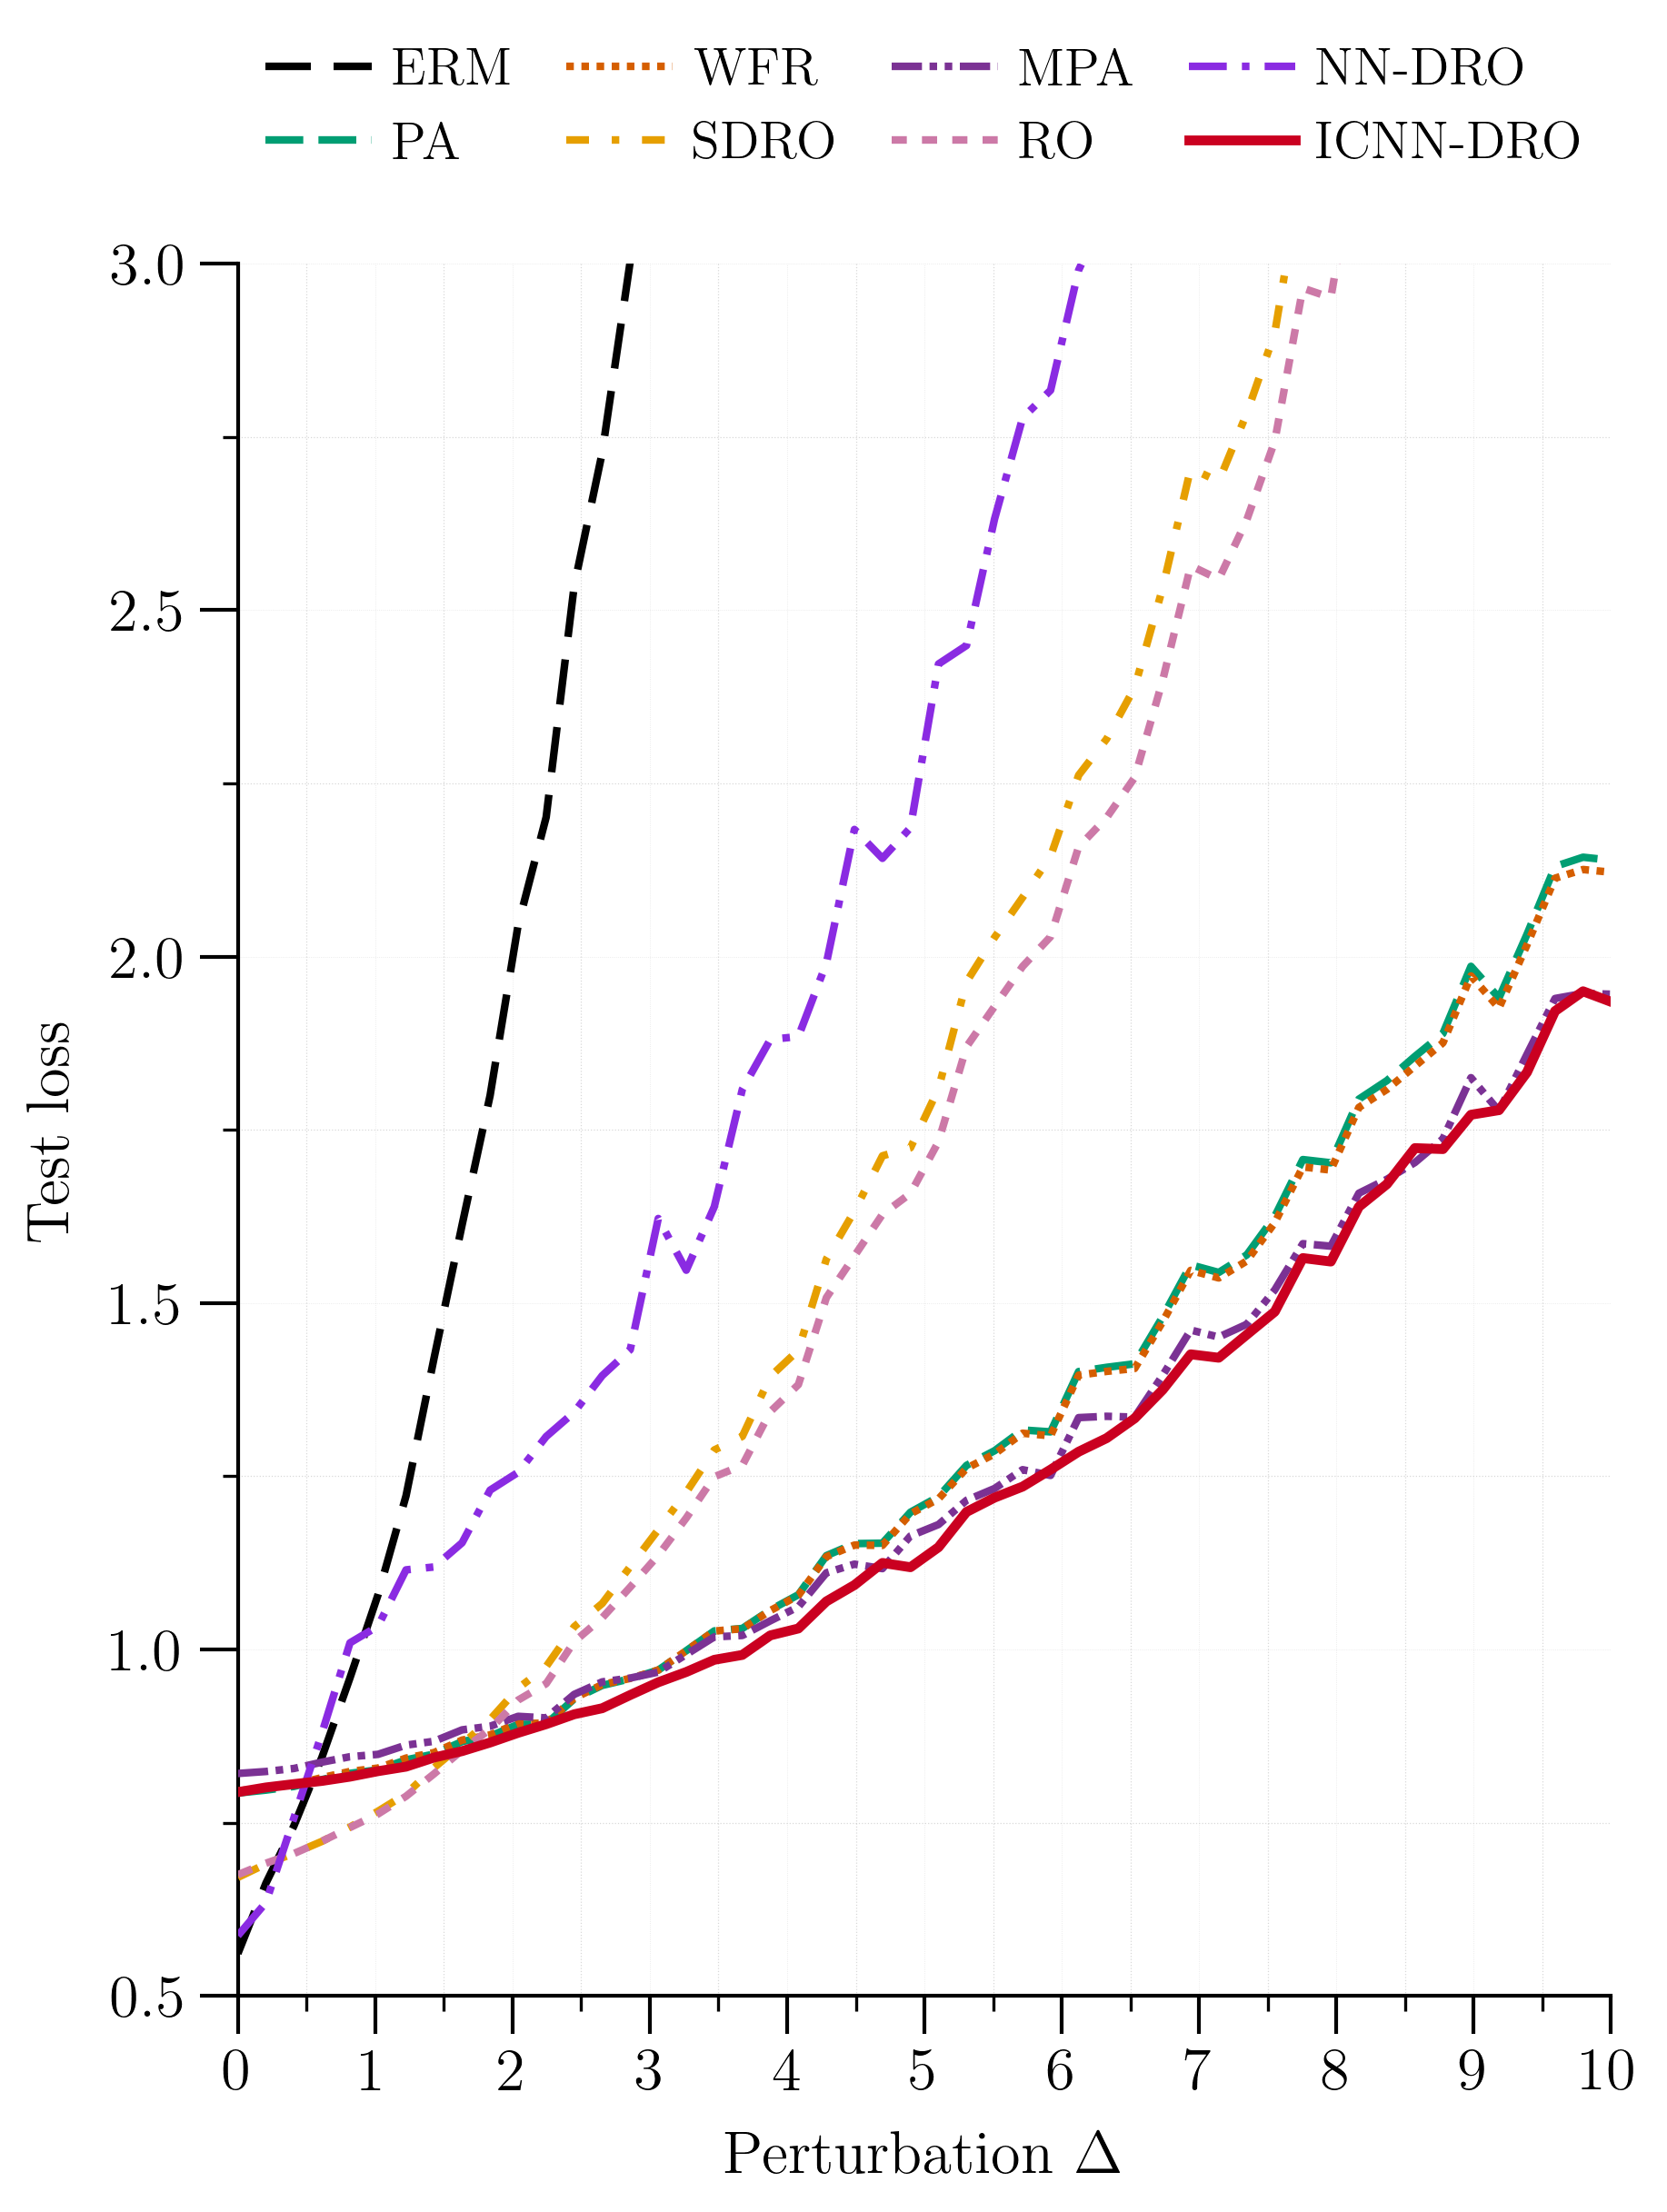

In [7]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── LaTeX / font configuration ────────────────────────────────────────────────
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "axes.spines.right": False,
    "axes.spines.top": False,
})

# ── Load results from JSON files ──────────────────────────────────────────────
# Filenames match utils/io.py save_results_json: non-alphanumeric runs -> "_",
# trailing "_" stripped. Update this map if you add/rename methods.
DATA_DIR = os.path.dirname(os.path.abspath("__file__"))  # notebook directory

# WGF and ICNN (WDRO-ICNN) are intentionally excluded from this figure.
METHOD_FILES = {
    "ERM":                     "ERM.json",
    "WFR(Xu, 2025)":           "WFR_Xu_2025.json",
    "Particle Ascent":         "Particle_Ascent.json",
    "Dual(Wang et al., 2021)": "Dual_Wang_et_al._2021.json",
    "Madry PGD":               "Madry_PGD.json",
    "PPA":                     "PPA.json",
    "WDRO-NPF":                "WDRO-NPF.json",
    "NN-DRO":                  "NN-DRO.json",
}

results = {}
delta_values = None
for name, fname in METHOD_FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.isfile(path):
        print(f"[skip] {fname} not found")
        continue
    with open(path) as f:
        data = json.load(f)
    results[name] = np.array(data["test_losses"])
    if delta_values is None:
        delta_values = np.array(data["delta_values"])

print(f"Loaded {len(results)} methods: {list(results.keys())}")

# ── Style definitions (matching utils/plot.py) ────────────────────────────────
styles = {
    "ERM":                     {"color": "#000000", "linestyle": (0, (6, 3))},
    "WFR(Xu, 2025)":           {"color": "#D55E00", "linestyle": (0, (1, 1))},
    "Particle Ascent":         {"color": "#009E73", "linestyle": (0, (5, 2))},
    "Dual(Wang et al., 2021)": {"color": "#E69F00", "linestyle": (0, (3, 3, 1, 3))},
    "Madry PGD":               {"color": "#CC79A7", "linestyle": (0, (2, 2))},
    "PPA":                     {"color": "#7B3294", "linestyle": (0, (4, 1, 1, 1, 1, 1))},
    "WDRO-NPF":                {"color": "#CA0020", "linestyle": "-"},
    "NN-DRO":                  {"color": "#8a2be2", "linestyle": (0, (5, 2, 1, 2))},
}

# WDRO-NPF is drawn LAST so it sits on top of PPA (whose curves may overlap).
plot_order = [
    "ERM",
    "Particle Ascent",
    "WFR(Xu, 2025)",
    "Dual(Wang et al., 2021)",
    "PPA",
    "Madry PGD",
    "NN-DRO",
    "WDRO-NPF",
]

# ── Plot ──────────────────────────────────────────────────────────────────────
# Taller than wide: y-axis is visually longer than x-axis.
fig, ax = plt.subplots(figsize=(6, 8), dpi=300, layout="constrained")

for name in plot_order:
    if name not in results:
        continue
    lw = 2.6 if name == "WDRO-NPF" else 2.0
    z = 5 if name == "WDRO-NPF" else 3
    ax.plot(
        delta_values, results[name],
        linewidth=lw,
        label=name,
        zorder=z,
        **styles[name],
    )

# ── Axes labels & limits ──────────────────────────────────────────────────────
ax.set_xlabel(r"Perturbation $\Delta$", labelpad=8)
ax.set_ylabel(r"Test loss", labelpad=8)

ax.set_xlim(float(delta_values.min()), float(delta_values.max()))
ax.set_ylim(0.5, 3.0)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

ax.tick_params(which="minor", length=4, width=0.8)

# ── Grid ──────────────────────────────────────────────────────────────────────
ax.grid(True, which="major", linestyle=":", linewidth=0.2, color="gray", alpha=0.2)
ax.grid(True, which="minor", linestyle=":", linewidth=0.3, color="gray", alpha=0.3)
ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────────────────────
legend = ax.legend(
    frameon=False,
    framealpha=0.95,
    edgecolor="0.75",
    fontsize=14,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),
    ncols=4,
    handlelength=2.0,
    handletextpad=0.4,
    columnspacing=1.0,
    borderaxespad=0.1,
)

# Paper-figure legend relabeling.
_legend_relabel = {
    "Particle Ascent":         "PA",
    "WFR(Xu, 2025)":           "WFR",
    "Dual(Wang et al., 2021)": "SDRO",
    "Madry PGD":               "RO",
    "PPA":                     "MPA",
    "WDRO-NPF":                "ICNN-DRO",
    "NN-DRO":                  "NN-DRO",
}
for text in legend.get_texts():
    label = text.get_text()
    if label in _legend_relabel:
        text.set_text(_legend_relabel[label])

# ── Spines ────────────────────────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.savefig("./fig8_uncertain_least_squares_all_methods_NNDRO.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("fig8_uncertain_least_squares_all_methods.png", dpi=300, bbox_inches="tight")
plt.show()


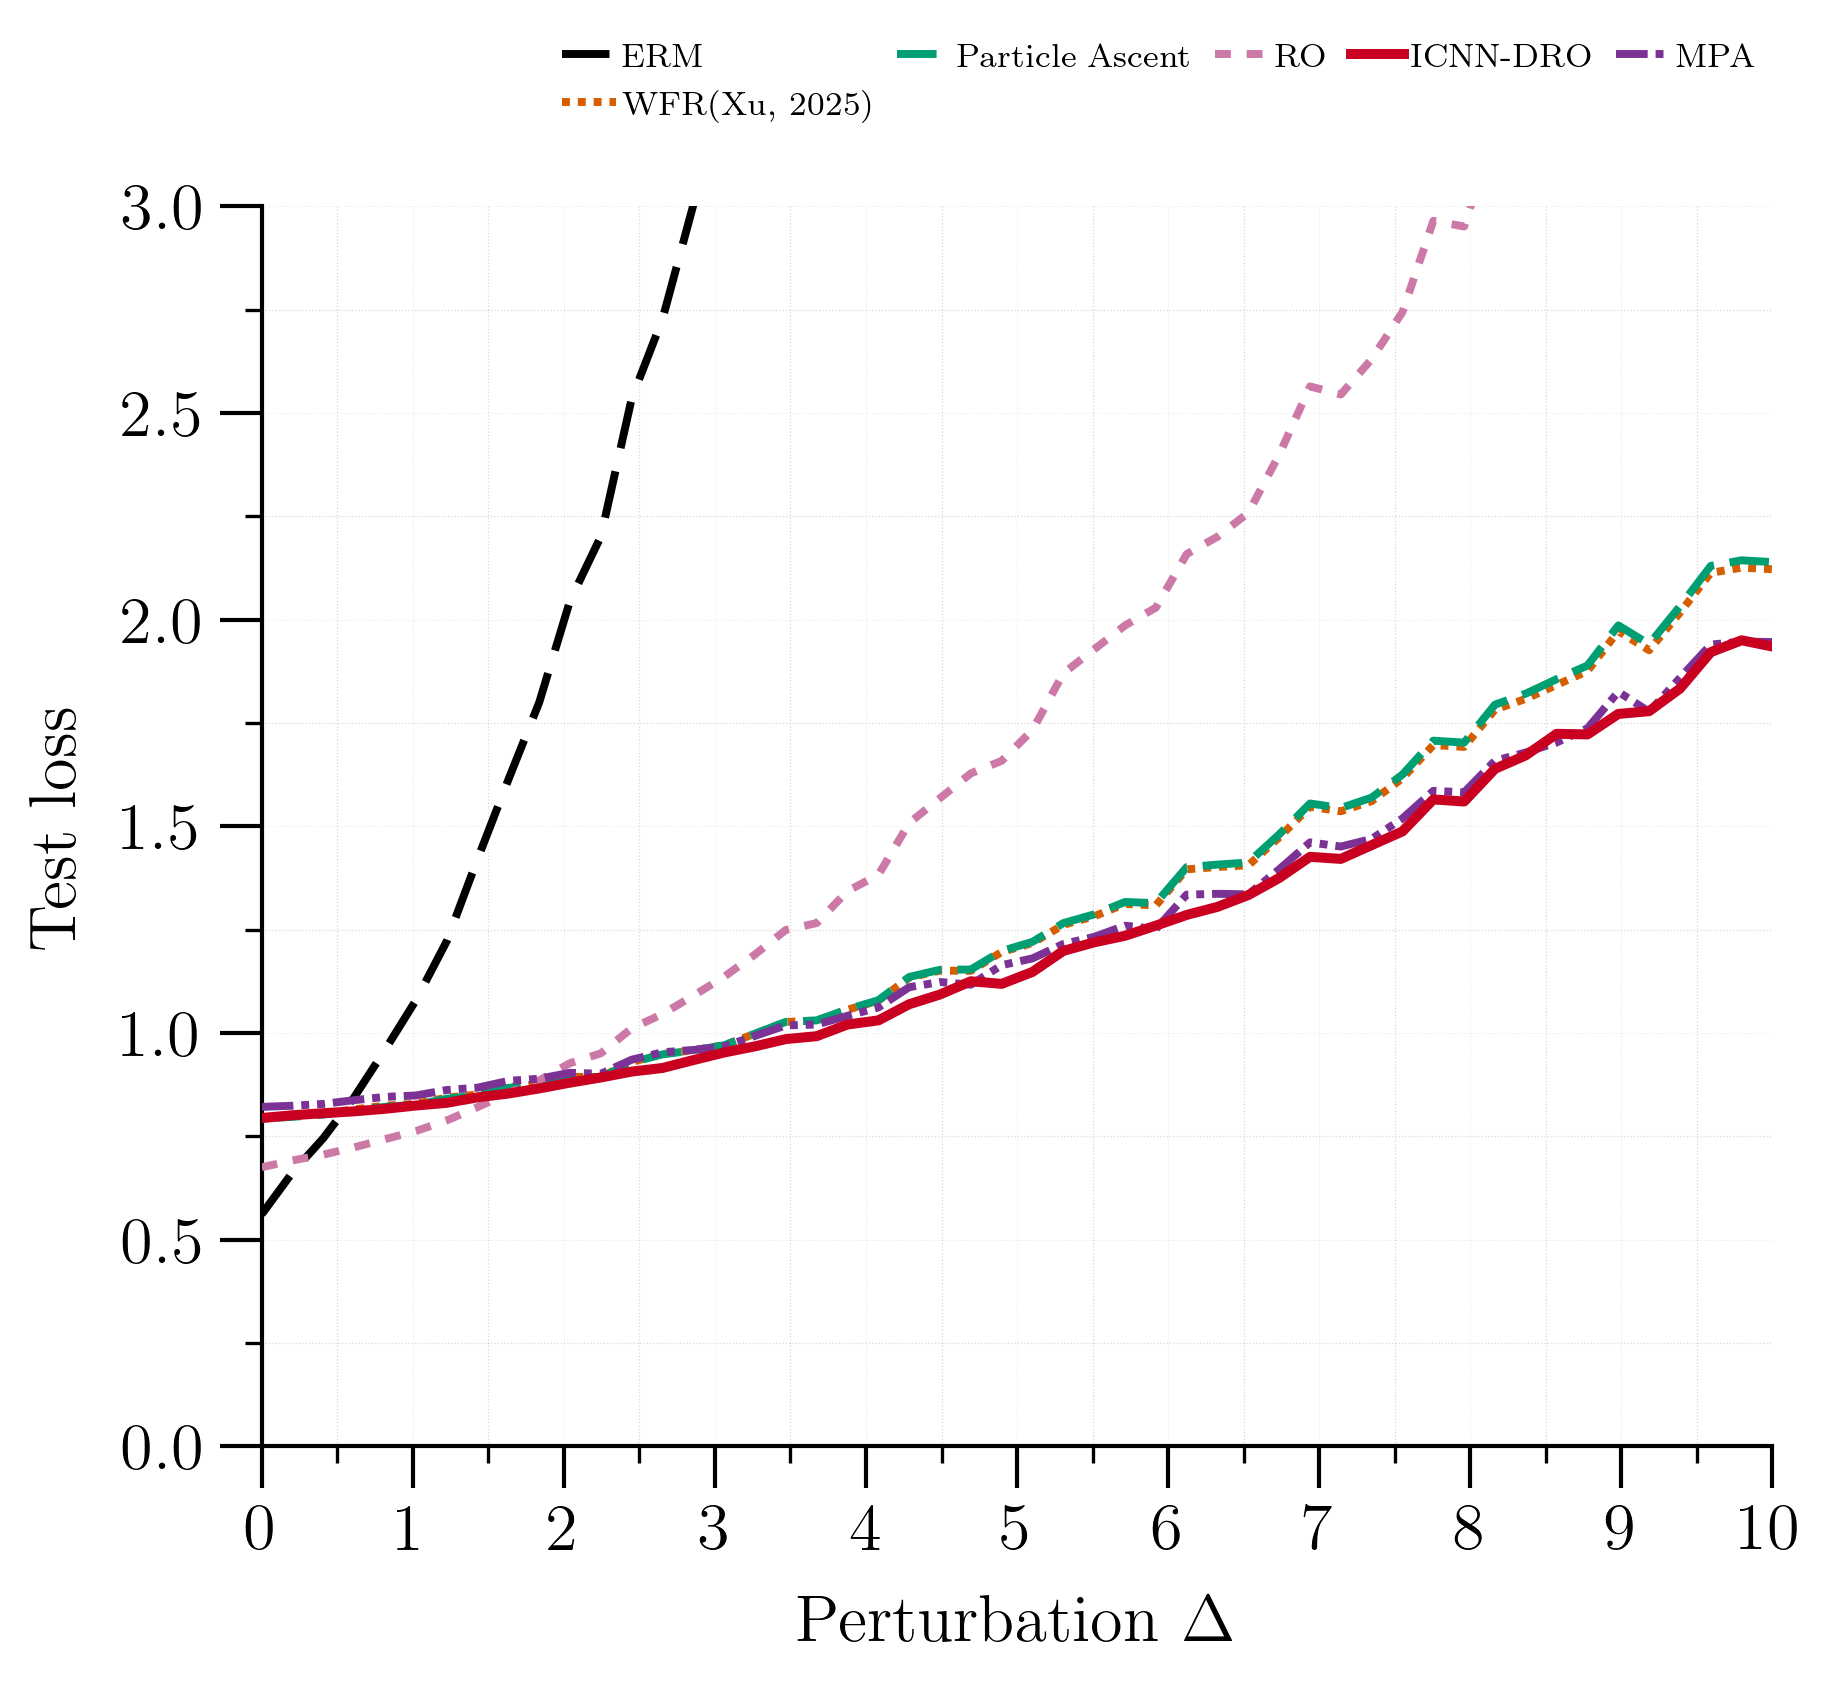

In [2]:
# Subset plot: ERM / WFR / Madry PGD / WDRO-NPF / PPA
# Reuses results/styles loaded in the cell above.

SUBSET = [
    "ERM",
    "WFR(Xu, 2025)",
    "Particle Ascent",
    "Madry PGD",
    "WDRO-NPF",
    "PPA",
]

fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300, layout="constrained")

for name in SUBSET:
    if name not in results:
        print(f"[skip] {name} not loaded")
        continue
    lw = 2.4 if name == "WDRO-NPF" else 1.9
    z = 5 if name == "WDRO-NPF" else 3
    ax.plot(
        delta_values, results[name],
        linewidth=lw,
        label=name,
        zorder=z,
        **styles[name],
    )

ax.set_xlabel(r"Perturbation $\Delta$", labelpad=8)
ax.set_ylabel(r"Test loss", labelpad=8)

ax.set_xlim(float(delta_values.min()), float(delta_values.max()))
ax.set_ylim(0.0, 3.0)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.tick_params(which="minor", length=4, width=0.8)

ax.grid(True, which="major", linestyle=":", linewidth=0.2, color="gray", alpha=0.2)
ax.grid(True, which="minor", linestyle=":", linewidth=0.3, color="gray", alpha=0.3)
ax.set_axisbelow(True)

legend = ax.legend(
    frameon=False,
    framealpha=0.95,
    edgecolor="0.75",
    fontsize=8,
    loc="center right",
    bbox_to_anchor=(1.0, 1.1),
    ncols=5,
    handlelength=1.6,
    handletextpad=0.2,
    columnspacing=0.7,
    borderaxespad=0.1,
)

_legend_relabel = {
    "Madry PGD": "RO",
    "PPA": "MPA",
    "WDRO-NPF": "ICNN-DRO",
}
for text in legend.get_texts():
    label = text.get_text()
    if label in _legend_relabel:
        text.set_text(_legend_relabel[label])

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.savefig("./fig8_uncertain_least_squares_subset.pdf", dpi=300, bbox_inches="tight")
plt.show()
